# Feature Selection

Pipeline:
1. Load preprocessed data (standard-scaled, OHE applied)
2. Train/test split — test set is locked away immediately
3. **Pearson filter** — remove numeric features with near-zero linear correlation
4. **RF importance filter** — remove features with low tree-based importance
5. Save final feature sets for model training

> Note: Permutation importance is skipped here as a selection step — it will be used post-training as a diagnostic tool. See model evaluation notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

RANDOM_SEED = 42
TARGET      = "Paddy yield(in Kg)"
DROP_COLS   = [TARGET, "Trash(in bundles)"]  # Trash is post-harvest, not a predictor

## 1. Load Data

In [2]:
df = pd.read_csv("C:\\dev\\Paddy_Prediction\\data\\transformed\\paddy_preprocessed_tree.csv")

X = df.drop(columns=DROP_COLS)
y = df[TARGET]

print(f"Dataset shape : {df.shape}")
print(f"Features      : {X.shape[1]}")
print(f"Target range  : {y.min():.0f} – {y.max():.0f} kg")

Dataset shape : (2789, 64)
Features      : 62
Target range  : 5410 – 38814 kg


## 2. Train / Test Split

Test set is locked away here and **never used** in any selection step.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED
)

print(f"Train : {X_train.shape[0]} rows")
print(f"Test  : {X_test.shape[0]} rows")

Train : 2231 rows
Test  : 558 rows


## 3. Helper — Detect OHE Columns

OHE (one-hot encoded) columns are binary (0/1). Pearson correlation is not meaningful for them, so they bypass the Pearson filter and are added back afterwards.

In [4]:
def detect_ohe_columns(X: pd.DataFrame) -> list:
    """
    Identify binary (0/1) columns, which are assumed to be one-hot encoded.

    Args:
        X: feature DataFrame

    Returns:
        List of column names that are binary
    """
    return [
        col for col in X.columns
        if set(X[col].dropna().unique()).issubset({0, 1})
    ]

ohe_cols = detect_ohe_columns(X_train)
print(f"OHE columns detected ({len(ohe_cols)}): {ohe_cols}")

OHE columns detected (27): ['Agriblock_Cuddalore', 'Agriblock_Kallakurichi', 'Agriblock_Kurinjipadi', 'Agriblock_Panruti', 'Agriblock_Sankarapuram', 'Variety_delux ponni', 'Variety_ponmani', 'Soil Types_clay', 'Nursery_wet', 'Wind Direction_D1_D30_ENE', 'Wind Direction_D1_D30_NW', 'Wind Direction_D1_D30_SSE', 'Wind Direction_D1_D30_SW', 'Wind Direction_D1_D30_W', 'Wind Direction_D31_D60_NE', 'Wind Direction_D31_D60_S', 'Wind Direction_D31_D60_W', 'Wind Direction_D31_D60_WNW', 'Wind Direction_D61_D90_NNE', 'Wind Direction_D61_D90_NNW', 'Wind Direction_D61_D90_SE', 'Wind Direction_D61_D90_SW', 'Wind Direction_D91_D120_NW', 'Wind Direction_D91_D120_S', 'Wind Direction_D91_D120_SSE', 'Wind Direction_D91_D120_W', 'Wind Direction_D91_D120_WSW']


## 4. Pearson Filter

Removes numeric features with absolute Pearson correlation below the threshold.
OHE columns are excluded from this step and added back after.

In [5]:
PEARSON_THRESHOLD = 0.01


def pearson_filter(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    threshold: float = 0.01
) -> tuple:
    """
    Select numeric features by absolute Pearson correlation with target.
    OHE columns are automatically excluded from this filter.

    Args:
        X_train   : training features
        y_train   : training target
        threshold : minimum absolute correlation to keep a feature

    Returns:
        selected_cols : list of selected numeric feature names
        corr_series   : full correlation series (sorted descending)
    """
    ohe_cols       = detect_ohe_columns(X_train)
    candidate_cols = [c for c in X_train.columns if c not in ohe_cols]

    correlations = {}
    for col in candidate_cols:
        if X_train[col].nunique() <= 1:
            continue
        corr, _ = pearsonr(X_train[col], y_train)
        correlations[col] = abs(corr)

    corr_series   = pd.Series(correlations).sort_values(ascending=False)
    selected_cols = corr_series[corr_series >= threshold].index.tolist()

    print(f"Pearson filter: {len(candidate_cols)} numeric → {len(selected_cols)} selected  (threshold={threshold})")
    return selected_cols, corr_series


pearson_cols, pearson_corr = pearson_filter(X_train, y_train, threshold=PEARSON_THRESHOLD)

# Add OHE columns back — they bypass the Pearson filter
final_pearson_cols = pearson_cols + ohe_cols
X_train_pearson    = X_train[final_pearson_cols]
X_test_pearson     = X_test[final_pearson_cols]

print(f"Total after adding OHE back: {len(final_pearson_cols)} features")

Pearson filter: 35 numeric → 29 selected  (threshold=0.01)
Total after adding OHE back: 56 features


In [6]:
final_pearson_cols

['Weed28D_thiobencarb',
 'LP_nurseryarea(in Tonnes)',
 'Hectares ',
 'Urea_40Days',
 'Potassh_50Days',
 'Seedrate(in Kg)',
 'LP_Mainfield(in Tonnes)',
 'Nursery area (Cents)',
 'Pest_60Day(in ml)',
 'Micronutrients_70Days',
 'DAP_20days',
 'Inst Wind Speed_D61_D90(in Knots)',
 'Inst Wind Speed_D1_D30(in Knots)',
 'Relative Humidity_D1_D30',
 'Min temp_D1_D30',
 'Min temp_D61_D90',
 '51_70AI(in mm)',
 '51_70DRain(in mm)',
 'Max temp_D61_D90',
 'Max temp_D91_D120',
 'Max temp_D1_D30',
 'Max temp_D31_D60',
 '30_50DAI(in mm)',
 '30_50DRain( in mm)',
 '71_105DAI(in mm)',
 '71_105DRain(in mm)',
 'Min temp_D31_D60',
 'Inst Wind Speed_D91_D120(in Knots)',
 'Inst Wind Speed_D31_D60(in Knots)',
 'Agriblock_Cuddalore',
 'Agriblock_Kallakurichi',
 'Agriblock_Kurinjipadi',
 'Agriblock_Panruti',
 'Agriblock_Sankarapuram',
 'Variety_delux ponni',
 'Variety_ponmani',
 'Soil Types_clay',
 'Nursery_wet',
 'Wind Direction_D1_D30_ENE',
 'Wind Direction_D1_D30_NW',
 'Wind Direction_D1_D30_SSE',
 'Wind Dire

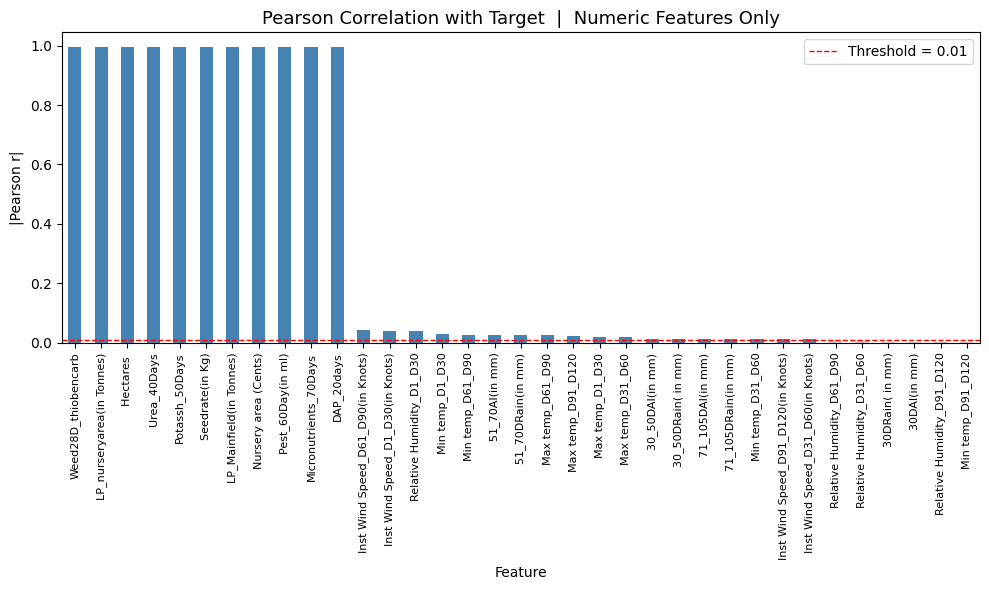

Saved → reports/figures/pearson_correlations.png


In [7]:
# --- Visualise Pearson correlations (numeric features only) ---

fig, ax = plt.subplots(figsize=(10, 6))

colors = ["steelblue" if v >= PEARSON_THRESHOLD else "#cccccc" for v in pearson_corr]
pearson_corr.plot(kind="bar", color=colors, ax=ax)

ax.axhline(PEARSON_THRESHOLD, color="red", linestyle="--", linewidth=1, label=f"Threshold = {PEARSON_THRESHOLD}")
ax.set_title("Pearson Correlation with Target  |  Numeric Features Only", fontsize=13)
ax.set_ylabel("|Pearson r|")
ax.set_xlabel("Feature")
ax.legend()
ax.tick_params(axis="x", labelsize=8)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
print("Saved → reports/figures/pearson_correlations.png")

## 5. Random Forest Importance Filter

Trained on the Pearson-filtered training set. Features below the importance threshold are dropped.

In [8]:
RF_IMPORTANCE_THRESHOLD = 0.001


def rf_importance_filter(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    threshold: float = 0.005
) -> tuple:
    """
    Select features using Random Forest mean-decrease-in-impurity (MDI) importance.

    Args:
        X_train   : training features (post-Pearson)
        y_train   : training target
        threshold : minimum importance score to retain a feature

    Returns:
        rf_model      : fitted RandomForestRegressor
        selected_cols : list of selected feature names
        importances   : full importance series (sorted descending)
    """
    rf_model = RandomForestRegressor(
        n_estimators=300,
        random_state=RANDOM_SEED,
        n_jobs=-1
    )
    rf_model.fit(X_train, y_train)

    importances   = pd.Series(rf_model.feature_importances_, index=X_train.columns)
    importances   = importances.sort_values(ascending=False)
    selected_cols = importances[importances >= threshold].index.tolist()

    print(f"RF importance filter: {len(X_train.columns)} → {len(selected_cols)} features  (threshold={threshold})")
    return rf_model, selected_cols, importances


rf_model, rf_cols, rf_importances = rf_importance_filter(
    X_train_pearson, y_train, threshold=RF_IMPORTANCE_THRESHOLD
)

RF importance filter: 56 → 11 features  (threshold=0.001)


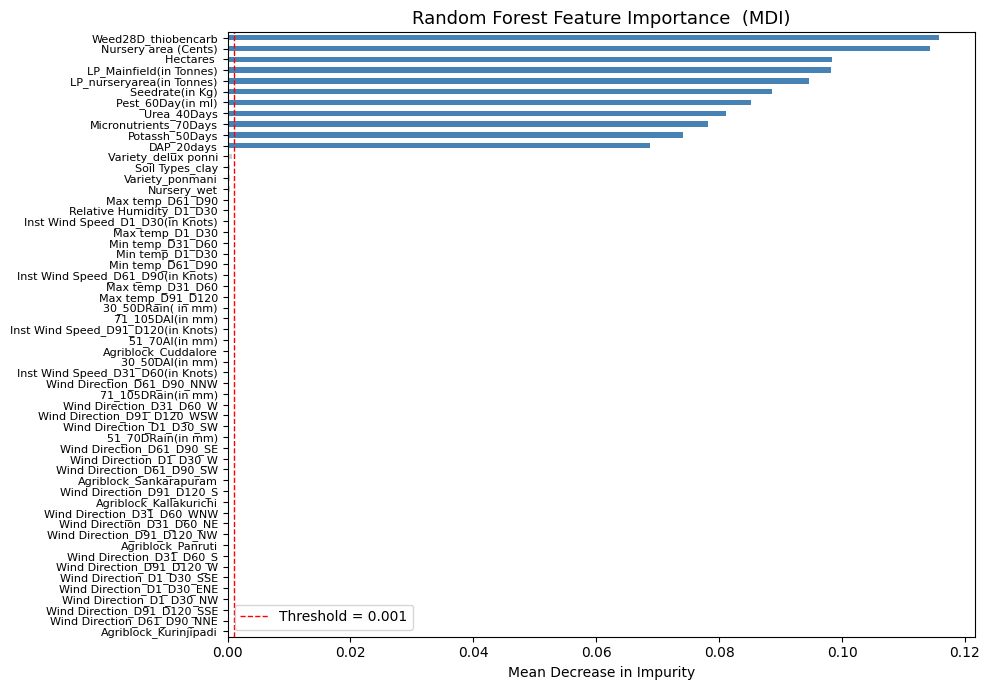

Saved → reports/figures/rf_feature_importance.png


In [9]:
# --- Visualise RF importances ---

fig, ax = plt.subplots(figsize=(10, 7))

colors = ["steelblue" if v >= RF_IMPORTANCE_THRESHOLD else "#cccccc" for v in rf_importances]
rf_importances.plot(kind="barh", color=colors, ax=ax)

ax.axvline(RF_IMPORTANCE_THRESHOLD, color="red", linestyle="--", linewidth=1, label=f"Threshold = {RF_IMPORTANCE_THRESHOLD}")
ax.invert_yaxis()
ax.set_title("Random Forest Feature Importance  (MDI)", fontsize=13)
ax.set_xlabel("Mean Decrease in Impurity")
ax.legend()
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.show()
print("Saved → reports/figures/rf_feature_importance.png")

## 6. Final Feature Set

In [10]:
X_train_final = X_train_pearson[rf_cols]
X_test_final  = X_test_pearson[rf_cols]

print(f"Final feature count : {len(rf_cols)}")
print(f"Train shape         : {X_train_final.shape}")
print(f"Test shape          : {X_test_final.shape}")
print(f"\nSelected features:\n{rf_cols}")

Final feature count : 11
Train shape         : (2231, 11)
Test shape          : (558, 11)

Selected features:
['Weed28D_thiobencarb', 'Nursery area (Cents)', 'Hectares ', 'LP_Mainfield(in Tonnes)', 'LP_nurseryarea(in Tonnes)', 'Seedrate(in Kg)', 'Pest_60Day(in ml)', 'Urea_40Days', 'Micronutrients_70Days', 'Potassh_50Days', 'DAP_20days']


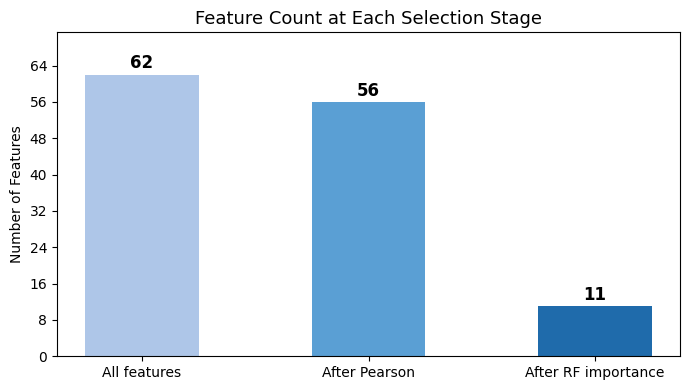

Saved → reports/figures/feature_selection_funnel.png


In [11]:
# --- Summary bar: features remaining at each stage ---

stages  = ["All features", "After Pearson", "After RF importance"]
counts  = [X.shape[1], len(final_pearson_cols), len(rf_cols)]
colors  = ["#aec6e8", "#5a9fd4", "#1f6bab"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(stages, counts, color=colors, width=0.5)

for bar, count in zip(bars, counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        str(count),
        ha="center", va="bottom", fontsize=12, fontweight="bold"
    )

ax.set_ylabel("Number of Features")
ax.set_title("Feature Count at Each Selection Stage", fontsize=13)
ax.set_ylim(0, max(counts) * 1.15)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()
print("Saved → reports/figures/feature_selection_funnel.png")

## 7. Save Outputs

In [12]:
import os
os.makedirs("../data/final", exist_ok=True)

X_train_final.to_csv("../data/final/X_train.csv", index=False)
X_test_final.to_csv("../data/final/X_test.csv",  index=False)
y_train.to_csv("../data/final/y_train.csv",       index=False)
y_test.to_csv("../data/final/y_test.csv",         index=False)

print("Saved to data/final/")
print("  X_train.csv  X_test.csv  y_train.csv  y_test.csv")

Saved to data/final/
  X_train.csv  X_test.csv  y_train.csv  y_test.csv


In [ ]:
X_train_final

,Weed28D_thiobencarb,Nursery area (Cents),Hectares,LP_Mainfield(in Tonnes),LP_nurseryarea(in Tonnes),Seedrate(in Kg),Pest_60Day(in ml),Urea_40Days,Micronutrients_70Days,Potassh_50Days,DAP_20days
599,10.0,100.0,5.0,0.892189,5.0,125.0,3000.0,0.892189,75.0,0.892189,200.0
1378,8.0,80.0,4.0,0.196546,4.0,100.0,2400.0,0.196546,60.0,0.196546,160.0
1717,6.0,60.0,3.0,-0.499097,3.0,75.0,1800.0,-0.499097,45.0,-0.499097,120.0
100,12.0,120.0,6.0,1.587832,6.0,150.0,3600.0,1.587832,90.0,1.587832,240.0
315,10.0,100.0,5.0,0.892189,5.0,125.0,3000.0,0.892189,75.0,0.892189,200.0
...,...,...,...,...,...,...,...,...,...,...,...
1638,8.0,80.0,4.0,0.196546,4.0,100.0,2400.0,0.196546,60.0,0.196546,160.0
1095,8.0,80.0,4.0,0.196546,4.0,100.0,2400.0,0.196546,60.0,0.196546,160.0
1130,8.0,80.0,4.0,0.196546,4.0,100.0,2400.0,0.196546,60.0,0.196546,160.0
1294,8.0,80.0,4.0,0.196546,4.0,100.0,2400.0,0.196546,60.0,0.196546,160.0


In [13]:
## for traditional models

# Load the scaled version of the full dataset
df_scaled = pd.read_csv("../data/transformed/paddy_preprocessed.csv")

# Extract only the 11 selected feature columns + target
X_scaled = df_scaled[rf_cols]  # same 11 column names
y = df_scaled[TARGET]

# Same split with same random seed — guarantees identical rows
X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Save
X_train_scaled.to_csv("../data/final/X_train_scaled.csv", index=False)
X_test_scaled.to_csv("../data/final/X_test_scaled.csv", index=False)

In [6]:
df["Variety"] = df[["Variety_ponmani", "Variety_delux ponni"]].idxmax(axis=1)
df["Variety"] = df["Variety"].str.replace("Variety_", "")